In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as ms
import pandas as pd

In [2]:
# pip install scikit-learn

In [65]:
ds1 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
ds2 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')
# ens = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/pH_ensemble_ssp585_merged.nc')

ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')

# bem = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/ph_ens_ssp126_biascorrected_mean.nc')

# ds4 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected.nc') 
# ds5 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/ph_ens_ssp585_biascorrected_mean.nc') 
ds3 = xr.open_dataset('/media/athira/One Touch/final_datasets/Review/Edited_plots/merged_files/REF_pH_v2.nc')
obs = xr.open_dataset('/media/athira/One Touch/final_datasets/Takahashi_clim_mask.nc')
# ds8 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Takahashi_GLOB_Grid_Dat.nc').ph


ds4= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_canesm_hist_mask.nc')
ds5= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_cesm2_hist_mask.nc')

ds6= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/ph_CESM2_historical_mask.nc')
ds7= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/ph_CMCC_historical_mask.nc')
ds8= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_gfdl-esm4_hist_mask.nc')
ds9= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/ph_IPSL_historical_mask.nc')
ds10= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_mpi-esm-hr_hist_mask.nc')
ds11= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-mm_hist_mask.nc')
ds12= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-lm_hist_mask.nc')

# ds3 = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/regrid_recon_ph_1deg.nc')
lat_range = slice(-30, 30)
lon_range = slice(30, 120)
# lat_range = slice(5, 27) 
# lon_range = slice(50, 100) 

# subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()
# subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)#.groupby('time.month').mean()


In [66]:
import xarray as xr
import numpy as np

def calculate_monthly_ph_rate(ds):

    ph = ds['ph'].sel(time=slice('1985-01-01', '2014-12-31'))

    # Extract year and month using xarray
    years = ph.time.dt.year.values
    months = ph.time.dt.month.values

    # Convert year to decimal year
    decimal_year = years + (months - 1) / 12.0

    rates = []

    for month in range(1, 13):

        # Select the particular month
        mask = months == month

        ph_month = ph.isel(time=mask)

        # Numeric year for regression
        year_month = decimal_year[mask]

        # Assign numeric year coordinate
        ph_month = ph_month.assign_coords(
            year=('time', year_month)
        )

        # Replace time dimension with numeric year
        ph_month = ph_month.swap_dims({'time': 'year'})

        # Linear regression: pH = intercept + slope × year
        fit = ph_month.polyfit(
            dim='year',
            deg=1,
            skipna=True
        )

        # Extract slope
        slope = fit['polyfit_coefficients'].sel(degree=1)

        # Remove lev dimension if it exists and has length 1
        if 'lev' in slope.dims and slope.sizes['lev'] == 1:
            slope = slope.squeeze('lev', drop=True)

        # Add month dimension
        slope = slope.expand_dims(month=[month])

        rates.append(slope)

    # Combine January–December
    rate = xr.concat(rates, dim='month')

    rate.name = 'ph_rate'
    rate.attrs['long_name'] = 'Monthly linear trend of pH'
    rate.attrs['units'] = 'pH units year-1'
    rate.attrs['period'] = '1985-2014'

    return rate

In [67]:
models = {
    'ds4': ds4,
    'ds5': ds5,
    'ds6': ds6,
    'ds7': ds7,
    'ds8': ds8,
    'ds9': ds9,
    'ds10': ds10,
    'ds11': ds11,
    'ds12': ds12,
    'ens': ens
    # 'bem':bem
}

ph_rates = {}

for name, model in models.items():
    print(f'Calculating pH rate for {name}...')

    ph_rates[name] = calculate_monthly_ph_rate(model)

    print(f'{name}: shape = {ph_rates[name].shape}')

Calculating pH rate for ds4...
ds4: shape = (12, 61, 90)
Calculating pH rate for ds5...
ds5: shape = (12, 61, 90)
Calculating pH rate for ds6...
ds6: shape = (12, 61, 91)
Calculating pH rate for ds7...
ds7: shape = (12, 61, 91)
Calculating pH rate for ds8...
ds8: shape = (12, 61, 90)
Calculating pH rate for ds9...
ds9: shape = (12, 61, 91)
Calculating pH rate for ds10...
ds10: shape = (12, 61, 90)
Calculating pH rate for ds11...
ds11: shape = (12, 61, 90)
Calculating pH rate for ds12...
ds12: shape = (12, 61, 90)
Calculating pH rate for ens...
ens: shape = (12, 61, 91)


In [68]:
# Calculate 1985–2014 monthly climatology
ph_climatologies = {}

for name, model in models.items():
    ph = model['ph'].sel(time=slice('1985-01-01', '2014-12-31'))

    # Monthly climatology
    clim = ph.groupby('time.month').mean('time', skipna=True)

    # Remove lev if it is a length-1 dimension
    if 'lev' in clim.dims and clim.sizes['lev'] == 1:
        clim = clim.squeeze('lev', drop=True)

    ph_climatologies[name] = clim

    print(f'{name}: climatology shape = {clim.shape}')

ds4: climatology shape = (12, 61, 90)
ds5: climatology shape = (12, 61, 90)
ds6: climatology shape = (12, 61, 91)
ds7: climatology shape = (12, 61, 91)
ds8: climatology shape = (12, 61, 90)
ds9: climatology shape = (12, 61, 91)
ds10: climatology shape = (12, 61, 90)
ds11: climatology shape = (12, 61, 90)
ds12: climatology shape = (12, 61, 90)
ens: climatology shape = (12, 61, 91)


In [69]:
# Years to shift
years_difference = 5.5

adjusted_ph = {}
ph_correction = {}

for name in models.keys():

    # Monthly pH rate (pH units/year)
    rate = ph_rates[name]

    # Correction = rate × 5.5 years
    correction = rate * years_difference

    # Store correction
    ph_correction[name] = correction

    # Original 1985–2014 monthly climatology
    clim = ph_climatologies[name]

    # Adjusted pH
    adjusted = clim + correction

    adjusted.name = 'ph_adjusted'
    adjusted.attrs['long_name'] = '1985–2014 monthly climatology adjusted by 5.5 years'
    adjusted.attrs['units'] = 'pH'
    adjusted.attrs['adjustment_period'] = '5.5 years'

    adjusted_ph[name] = adjusted

    print(f'{name}: adjusted pH shape = {adjusted.shape}')

ds4: adjusted pH shape = (12, 61, 90)
ds5: adjusted pH shape = (12, 61, 90)
ds6: adjusted pH shape = (12, 61, 91)
ds7: adjusted pH shape = (12, 61, 91)
ds8: adjusted pH shape = (12, 61, 90)
ds9: adjusted pH shape = (12, 61, 91)
ds10: adjusted pH shape = (12, 61, 90)
ds11: adjusted pH shape = (12, 61, 90)
ds12: adjusted pH shape = (12, 61, 90)
ens: adjusted pH shape = (12, 61, 91)


In [70]:
# Assign adjusted pH climatology to individual variables

ds4_pH  = adjusted_ph['ds4']
ds5_pH  = adjusted_ph['ds5']
ds6_pH  = adjusted_ph['ds6']
ds7_pH  = adjusted_ph['ds7']
ds8_pH  = adjusted_ph['ds8']
ds9_pH  = adjusted_ph['ds9']
ds10_pH = adjusted_ph['ds10']
ds11_pH = adjusted_ph['ds11']
ds12_pH = adjusted_ph['ds12']
ens_pH  = adjusted_ph['ens']
# bem_pH = adjusted_ph['bem']

In [71]:
ds4_pH

<xarray.DataArray 'ph_adjusted' (month: 12, lat: 61, lon: 90)> Size: 527kB
array([[[       nan,        nan, 8.06834164, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.0645372 , ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.07681031, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 61, 90))
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    degree    int64 8B 1
Attributes:
    long_name:          1985–2014 monthly climatology adjusted by 5.5 years
    units:              pH
    period:             1985-2014
    adjustment_period:  5.5 years

In [72]:
# ds3

In [73]:
# subset_ds1 = ds1.sel(lat=lat_range, lon=lon_range)#, time=slice('1993', '2014')).groupby('time.month').mean()
# subset_ds2 = ds2.sel(lat=lat_range, lon=lon_range)#, time=slice('1993', '2014')).groupby('time.month').mean()

# subset_ds1['time'] = subset_ds1.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2.indexes['time'].to_period('M').to_timestamp()

# # Interpolate ds2 onto ds1 grid (lat, lon, time)
# subset_ds2_interp = subset_ds2.interp(
#     lat=subset_ds1['lat'],
#     lon=subset_ds1['lon'],
#     time=subset_ds1['time'],
#     method='linear'
# )

# # Calculate mean pH
# ph_mean = xr.concat(
#     [subset_ds1['ph'], subset_ds2_interp['ph']],
#     dim='model'
# ).mean(dim='model')

# subset_ds3_sub = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds4_sub = ds4_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds5_sub = ds5_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds6_sub = ds6_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds7_sub = ds7_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds8_sub = ds8_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds9_sub = ds9_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds10_sub = ds10_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds11_sub = ds11_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
subset_ds12_sub = ds12_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
obs = obs.sel(lat=lat_range, lon=lon_range)

ens_sub = ens_pH.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()
# obs_sub = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()
# subset_ds1['time'] = subset_ds1_sub.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2_sub.indexes['time'].to_period('M').to_timestamp()

# bem_sub = bem.sel(lat=lat_range, lon=lon_range)#, time=slice('1985', '2014')).groupby('time.month').mean()


obs = obs.rename_dims({
    "time": "month",
})

# # Rename coordinates (important!)
# ds3 = ds3.rename_vars({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon",
#     "pH": "ph"
# })
# ds3_sub = ds3.sel(lat=lat_range, 
# lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()


In [74]:
ens_sub

<xarray.DataArray 'ph_adjusted' (month: 12, lat: 61, lon: 91)> Size: 533kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(12, 61, 91))
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    lev       float64 8B ...
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    method    <U7 28B ...
    olevel    float32 4B ...
    degree    int64 8B 1
Attributes:
    long_name:          1985–2014 monthly climatology adjusted by 5.5 years
    units:              pH
    period:             1985-2014
    adjustment_period:  5.5 years

In [75]:
obs#ds8.ph#.isel(time=0).ph.plot()

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
  * time      (month) datetime64[ns] 96B 2005-01-16T12:00:00 ... 2005-12-16T1...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
Dimensions without coordinates: month
Data variables:
    ph        (month, lat, lon) float64 527kB ...

In [76]:
# lat_tgt = subset_ds8_sub.lat
# lon_tgt = subset_ds8_sub.lon
lat_tgt = obs.lat
lon_tgt = obs.lon

In [77]:
ph_mod_rg = subset_ds12_sub.interp(
    lat=lat_tgt,
    lon=lon_tgt,
    method="linear"
)


In [78]:
# ph_obs_mon = ds3_sub.assign_coords(
#     month=ds3_sub.time.dt.month
# ).swap_dims({"time": "month"}).drop("time")


In [79]:
ph_mod = subset_ds12_sub#.ph#.sel(lev=ph_mod_rg.lev.values[0])  



In [80]:
ph_mod

<xarray.DataArray 'ph_adjusted' (month: 12, lat: 61, lon: 90)> Size: 527kB
array([[[       nan,        nan, 8.07493339, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.0703288 , ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.08130727, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 61, 90))
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    degree    int64 8B 1
Attributes:
    long_name:          1985–2014 monthly climatology adjusted by 5.5 years
    units:              pH
    period:             1985-2014
    adjustment_period:  5.5 years

In [81]:
ph_mod = ph_mod.transpose('month', 'lat', 'lon')
ph_obs = obs.transpose('month', 'lat', 'lon')


In [82]:
ph_mod

<xarray.DataArray 'ph_adjusted' (month: 12, lat: 61, lon: 90)> Size: 527kB
array([[[       nan,        nan, 8.07493339, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.0703288 , ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.08130727, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]]], shape=(12, 61, 90))
Coordinates:
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    degree    int64 8B 1
Attributes:
    long_name:          1985–2014 monthly climatology adjusted by 5.5 years
    units:              pH
    period:             1985-2014
    adjustment_period:  5.5 years

In [83]:
ph_obs

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
  * time      (month) datetime64[ns] 96B 2005-01-16T12:00:00 ... 2005-12-16T1...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
Dimensions without coordinates: month
Data variables:
    ph        (month, lat, lon) float64 527kB ...

In [84]:
print(ph_mod)
print(ph_obs)

<xarray.DataArray 'ph_adjusted' (month: 12, lat: 61, lon: 90)> Size: 527kB
array([[[       nan,        nan, 8.07493339, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan, 8.0703288 , ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [       nan,        nan,        na

In [85]:
# Align grids
# ph_mod, ph_obs = xr.align(ph_mod, ph_obs)

# # Create masks
# mask_mod = np.isnan(ph_mod)
# mask_obs = np.isnan(ph_obs)

# # Union mask
# common_mask = mask_mod | mask_obs

# # Apply
# ph_mod_common = ph_mod.where(~common_mask)
# ph_obs_common = ph_obs.where(~common_mask)

# # Final check
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print("Identical masks:", np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


# Make sure ph_obs is the DataArray
ph_obs = ph_obs['ph']

# Interpolate/regrid model onto observation grid
ph_mod_regrid = ph_mod.interp(
    lat=ph_obs.lat,
    lon=ph_obs.lon,
    method='nearest'
)

# Now they should have the same dimensions
print(ph_mod_regrid.shape)
print(ph_obs.shape)

# Create NaN masks
mask_mod = np.isnan(ph_mod_regrid)
mask_obs = np.isnan(ph_obs)

# Common mask: NaN if either dataset has NaN
common_mask = mask_mod | mask_obs

# Apply the same mask to both
ph_mod_common = ph_mod_regrid.where(~common_mask)
ph_obs_common = ph_obs.where(~common_mask)

# Final check
mask1_new = np.isnan(ph_mod_common)
mask2_new = np.isnan(ph_obs_common)

print("Model shape:", ph_mod_common.shape)
print("Observation shape:", ph_obs_common.shape)

print("Identical masks:", np.array_equal(mask1_new, mask2_new))
print("Model NaNs:", mask1_new.sum().item())
print("Observation NaNs:", mask2_new.sum().item())

(12, 61, 90)
(12, 61, 90)
Model shape: (12, 61, 90)
Observation shape: (12, 61, 90)
Identical masks: True
Model NaNs: 36000
Observation NaNs: 36000


In [86]:
# print(ph_obs_final.shape)
# print(ph_mod_final.shape)

# print(np.isnan(ph_obs_final).sum().item(),
#       np.isnan(ph_mod_final).sum().item())
# mask1 = np.isnan(ph_mod_final.ph)
# mask2 = np.isnan(ph_obs_final.ph)

# same_nan_mask = np.array_equal(mask1, mask2)

# print("NaN masks identical:", same_nan_mask)
# print("NaNs in ds1:", mask1.sum().item())
# print("NaNs in ds2:", mask2.sum().item())
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print(np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


In [87]:
def Taylor_skill(ref, mod):
    ref = np.array(ref)
    mod = np.array(mod)
    std_ratio = np.std(mod) / np.std(ref)
    corr = np.corrcoef(ref.flatten(), mod.flatten())[0, 1]
    tss = ((1 + corr) ** 2) / ((std_ratio + 1 / std_ratio) ** 2)
    return tss

# Apply spatially using xarray
def calculate_tss_spatially(ref_ds, mod_ds):

    skill = xr.apply_ufunc(
        Taylor_skill,             # Function to apply
        ref_ds,                   # Reference dataset
        mod_ds,                   # Model dataset
        input_core_dims=[['month'], ['month']],  # Apply over 'year' dimension
        vectorize=True,           # Vectorize the function for broadcasting
        dask="parallelized",      # Enable Dask for large data
        output_dtypes=[float]     # Output type
    )
    return skill

In [88]:
skill_cmems = calculate_tss_spatially(ph_obs_common, ph_mod_common)

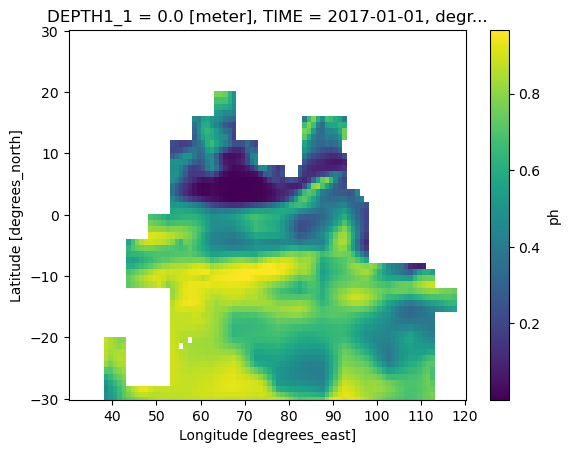

In [89]:
skill_cmems.plot()

In [90]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

skill_bias_as = skill_cmems.sel(lat=lat_range_as, lon=lon_range_as).mean()
skill_bias_as

<xarray.DataArray 'ph' ()> Size: 8B
array(0.26987556)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    degree    int64 8B 1

In [91]:
lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

skill_bias_bob = skill_cmems.sel(lat=lat_range_bob, lon=lon_range_bob).mean()
skill_bias_bob

<xarray.DataArray 'ph' ()> Size: 8B
array(0.37449188)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    degree    int64 8B 1

In [92]:
lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

skill_bias_cio = skill_cmems.sel(lat=lat_range_cio, lon=lon_range_cio).mean()
skill_bias_cio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.68562405)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    degree    int64 8B 1

In [93]:
lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

skill_bias_sio = skill_cmems.sel(lat=lat_range_sio, lon=lon_range_sio).mean()
skill_bias_sio

<xarray.DataArray 'ph' ()> Size: 8B
array(0.70440483)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    degree    int64 8B 1